# Welcome to RAG week!!

## Expert Knowledge Worker

### A question answering Assistant that is an expert knowledge worker
### To be used by employees of Insurellm, an Insurance Tech company
### The AI assistant needs to be accurate and the solution should be low cost.

This project will use RAG (Retrieval Augmented Generation) to ensure our question/answering assistant has high accuracy.

This first implementation will use a simplistic, brute-force type of RAG..


In [1]:
import os
import glob
from dotenv import load_dotenv
from pathlib import Path
import gradio as gr
from openai import OpenAI

In [2]:
# Setting up

load_dotenv(override=True)

openrouter = OpenAI(
    api_key=os.getenv('OPENROUTER_API_KEY'),
    base_url="https://openrouter.ai/api/v1"
)
MODEL = "meta-llama/llama-3.3-70b-instruct"

### Let's read in all employee data into a dictionary

In [3]:
knowledge = {}

filenames = glob.glob("knowledge-base/employees/*")

for filename in filenames:
    name = Path(filename).stem.split(' ')[-1]
    with open(filename, "r", encoding="utf-8") as f:
        knowledge[name.lower()] = f.read()

In [4]:
knowledge

{'chen': "# HR Record\n\n# Robert Chen\n\n## Summary\n- **Date of Birth:** February 28, 1983\n- **Job Title:** Senior Full Stack Engineer\n- **Location:** San Francisco, California\n- **Current Salary:** $152,000\n\n## Insurellm Career Progression\n- **January 2016 - Present:** Senior Full Stack Engineer\n  - Technical lead for Homellm home insurance portal\n  - Architects full-stack solutions using React, Node.js, and PostgreSQL\n  - Mentors team of 6 engineers\n  - Led 3 major platform releases\n\n- **June 2012 - December 2015:** Full Stack Developer at WebSolutions Inc.\n  - Built web applications for enterprise clients\n  - Worked with various JavaScript frameworks and backend technologies\n\n- **August 2008 - May 2012:** Software Engineer at TechStartup\n  - Developed features for SaaS platform\n  - Gained experience across full technology stack\n\n## Annual Performance History\n- **2023:** Rating: 4.8/5\n  *Exceptional performance. Led critical platform modernization project. Out

In [6]:
knowledge["lancaster"]

"# Avery Lancaster\n\n## Summary\n- **Date of Birth**: March 15, 1985\n- **Job Title**: Co-Founder & Chief Executive Officer (CEO)\n- **Location**: San Francisco, California\n- **Current Salary**: $225,000  \n\n## Insurellm Career Progression\n- **2015 - Present**: Co-Founder & CEO  \n  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  \n\n- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  \n  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at the tech sector.  \n\n- **2010 - 2013**: Business Analyst at Edge Analytics  \n  Prior to joining Innovate, Avery worked as a Business Analyst, focusing on market t

In [7]:
filenames = glob.glob("knowledge-base/products/*")

for filename in filenames:
    name = Path(filename).stem
    with open(filename, "r", encoding="utf-8") as f:
        knowledge[name.lower()] = f.read()

In [8]:
knowledge.keys()

dict_keys(['chen', 'harper', 'thomson', 'foster', 'lancaster', 'walker', 'rodriguez', 'park', 'kim', 'carter', 'tran', 'wilson', 'adams', 'liu', 'blake', 'bishop', 'zhang', 'anderson', 'johnson', 'thompson', "o'brien", 'rivera', 'patel', 'spencer', 'sharma', 'martinez', 'greene', 'trenton', 'williams', 'brooks', 'bizllm', 'carllm', 'claimllm', 'healthllm', 'homellm', 'lifellm', 'markellm', 'rellm'])

In [9]:
SYSTEM_PREFIX = """
You represent Insurellm, the Insurance Tech company.
You are an expert in answering questions about Insurellm; its employees and its products.
You are provided with additional context that might be relevant to the user's question.
Give brief, accurate answers. If you don't know the answer, say so.

Relevant context:
"""

In [10]:
def get_relevant_context_simple(message):
    text = ''.join(ch for ch in message if ch.isalpha() or ch.isspace())
    words = text.lower().split()
    relevant_context = []
    for word in words:
        if word in knowledge:
            relevant_context.append(knowledge[word])
    return relevant_context          

## But a more pythonic way:

In [11]:
def get_relevant_context(message):
    text = ''.join(ch for ch in message if ch.isalpha() or ch.isspace())
    words = text.lower().split()
    return [knowledge[word] for word in words if word in knowledge]   

In [12]:
get_relevant_context("Who is lancaster?")

["# Avery Lancaster\n\n## Summary\n- **Date of Birth**: March 15, 1985\n- **Job Title**: Co-Founder & Chief Executive Officer (CEO)\n- **Location**: San Francisco, California\n- **Current Salary**: $225,000  \n\n## Insurellm Career Progression\n- **2015 - Present**: Co-Founder & CEO  \n  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  \n\n- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  \n  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at the tech sector.  \n\n- **2010 - 2013**: Business Analyst at Edge Analytics  \n  Prior to joining Innovate, Avery worked as a Business Analyst, focusing on market 

In [13]:
get_relevant_context("Who is Lancaster and what is carllm?")

["# Avery Lancaster\n\n## Summary\n- **Date of Birth**: March 15, 1985\n- **Job Title**: Co-Founder & Chief Executive Officer (CEO)\n- **Location**: San Francisco, California\n- **Current Salary**: $225,000  \n\n## Insurellm Career Progression\n- **2015 - Present**: Co-Founder & CEO  \n  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  \n\n- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  \n  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at the tech sector.  \n\n- **2010 - 2013**: Business Analyst at Edge Analytics  \n  Prior to joining Innovate, Avery worked as a Business Analyst, focusing on market 

In [14]:
def additional_context(message):
    relevant_context = get_relevant_context(message)
    if not relevant_context:
        result = "There is no additional context relevant to the user's question."
    else:
        result = "The following additional context might be relevant in answering the user's question:\n\n"
        result += "\n\n".join(relevant_context)
    return result

In [15]:
print(additional_context("Who is Alex Lancaster?"))

The following additional context might be relevant in answering the user's question:

# Avery Lancaster

## Summary
- **Date of Birth**: March 15, 1985
- **Job Title**: Co-Founder & Chief Executive Officer (CEO)
- **Location**: San Francisco, California
- **Current Salary**: $225,000  

## Insurellm Career Progression
- **2015 - Present**: Co-Founder & CEO  
  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  

- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  
  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at the tech sector.  

- **2010 - 2013**: Business Analyst at Edge Analytics  
  Prior to joini

In [16]:
def chat(message, history):
    system_message = SYSTEM_PREFIX + additional_context(message)
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openrouter.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

## Now we will bring this up in Gradio using the Chat interface -

A quick and easy way to prototype a chat with an LLM

In [17]:
view = gr.ChatInterface(chat, type="messages").launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


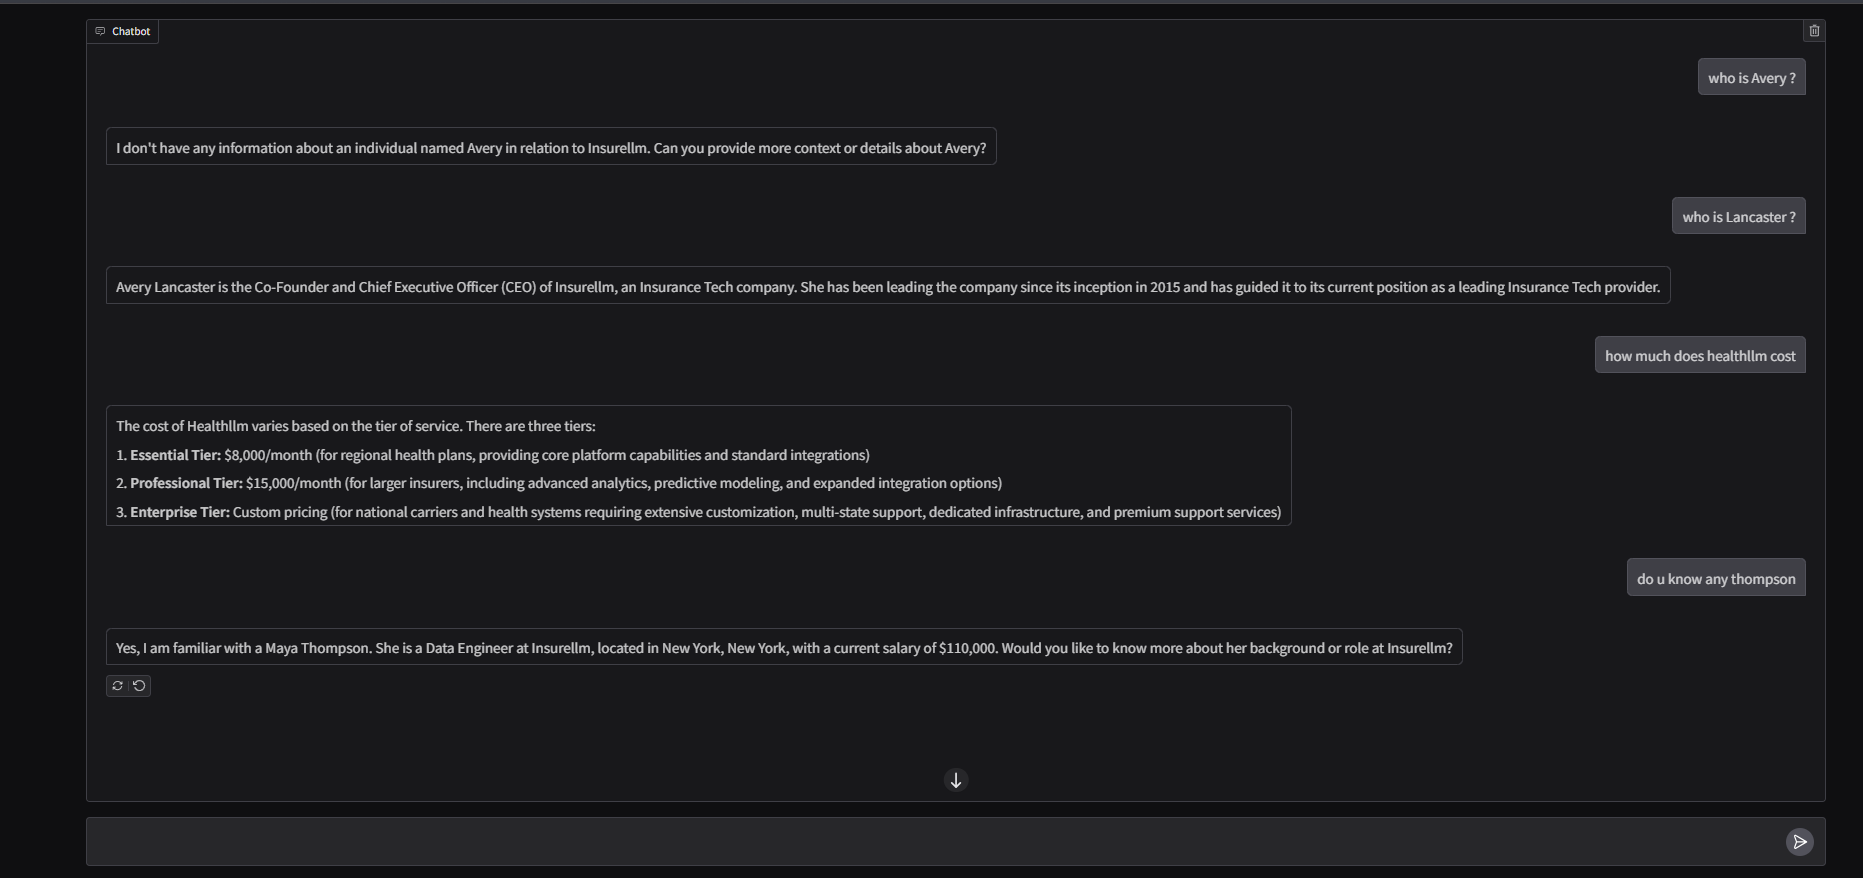